In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from featureEngineer import engineer_features

from pathlib import Path
import sys
import os
from datetime import datetime
from dataScraper import *

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

## The objective of this notebook is to understand how Minutes work
### What leads to a players minutes
- Role
- Health/status
- opponent matchup
- game script (spread, pace, blowout risk)
- coach tendencies
- recent performance


In [ ]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')

data = []
for i in [s25, s26]:
    i['MIN'] = i['MIN'].round(2)
    i['STARTING'] = i['START_POSITION'].notna().astype(int)
    df = engineer_features(i)
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_POSS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_POSS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['POSS_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['MEDIAN_PTS_ROLLING_10'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df['PTS_ewm5'] = (
    df.groupby('PLAYER_ID')['PTS']
    .transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['PTS_ewm10'] = (
        df.groupby('PLAYER_ID')['PTS']
        .transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    data.append(df)

# data['GAME_DATE'] = pd.to_datetime(data['GAME_DATE']).dt.strftime('%Y-%m-%d')

# print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")

## Filter data 

In [ ]:
# Compute player-level averages (across all their games in the dataset)
player_avgs = data.groupby('PLAYER_ID').agg(
    avg_MIN=('MIN', 'mean'),
    avg_PTS=('PTS', 'mean')
).reset_index()

# Keep only players who average >10 min AND >=5 ppg
eligible_players = player_avgs[
    (player_avgs['avg_MIN'] > 10) & 
    (player_avgs['avg_PTS'] >= 5)
]['PLAYER_ID']

# Filter data to only include these players
data = data[data['PLAYER_ID'].isin(eligible_players)]

# IQR method for PTS outliers
Q1 = data['PTS'].quantile(0.25)
Q3 = data['PTS'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove rows where PTS is outside the bounds
data = data[(data['PTS'] >= lower_bound) & (data['PTS'] <= upper_bound)]
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")
data.tail()

The dataset has 60714 rows and 227 columns.


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,STARTING,MIN_roll5,PTS_roll5,USG_PCT_roll5,PIE_roll5,PLUS_MINUS_roll5,POSS_roll5,MIN_roll7,PTS_roll7,USG_PCT_roll7,PIE_roll7,PLUS_MINUS_roll7,POSS_roll7,MIN_roll10,PTS_roll10,USG_PCT_roll10,PIE_roll10,PLUS_MINUS_roll10,POSS_roll10,MIN_roll20,PTS_roll20,USG_PCT_roll20,PIE_roll20,PLUS_MINUS_roll20,POSS_roll20,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,PTS_PER_MIN_roll5,NET_RATING_roll5,TS_PCT_roll5,TEAM_PACE_roll5,TEAM_PTS_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,PTS_std5,PTS_std10,TEAM_MIN_RANK_L5,TEAM_MIN_RANK_L10,TEAM_PTS_RANK_L5,TEAM_PTS_RANK_L10,TEAM_POSS_RANK_L5,TEAM_POSS_RANK_L10,TEAM_USG_RANK_L5,TEAM_USG_RANK_L10,MEDIAN_PTS_ROLLING_10,PTS_ewm5,PTS_ewm10,POSITION
75470,2025-26,1643158,Andersson Garcia,Andersson,1610612762,UTA,Utah Jazz,22500949,2026-03-11,UTA vs. NYK,L,25.05,2,5,0.400,0,0,0.000,2,2,1.000,5,4,9,0,1,1,1,0,4,1,6,-31,21.8,0,0,19.0,1,25:03,1,95.0,90.2,90.2,152.8,154.0,154.0,-57.7,-63.8,-63.8,0.000,0.00,0.0,0.172,0.190,0.180,14.3,14.5,0.400,0.510,0.123,0.126,94.66,96.77,80.64,96.77,0.052,51,2.0,5.0,42,87,0.483,18,36,0.500,15,19,0.789,14,24,38,30,15.0,7,4,3,20,16,117,-17.0,121.4,118.2,135.8,138.1,-14.4,-20.0,0.714,2.00,20.8,0.340,0.636,0.484,0.152,0.586,0.613,97.5,98.0,81.67,99,0.412,1610612752,NYK,New York Knicks,48,92,0.522,17,40,0.425,21,22,0.955,15,30,45,37,12.0,10,3,4,16,20,134,17.0,135.8,138.1,121.4,118.2,14.4,20.0,0.771,3.08,24.7,0.364,0.660,0.516,0.124,0.614,0.659,97.5,98.0,81.67,97,0.588,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.2,113.4,NaN,NaN,66.8,NaN,3.0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F
75471,2025-26,1643158,Andersson Garcia,Andersson,1610612762,UTA,Utah Jazz,22500967,2026-03-13,UTA @ POR,L,28.55,2,6,0.333,0,3,0.000,2,2,1.000,2,1,3,2,3,2,0,0,4,4,6,-11,15.6,0,0,15.0,1,28:33,1,86.3,88.7,88.7,106.0,103.1,103.1,-19.7,-14.4,-14.4,0.111,0.67,16.7,0.057,0.032,0.045,25.0,25.3,0.333,0.436,0.137,0.138,105.92,105.92,88.27,105.92,0.009,62,2.0,6.0,42,92,0.457,13,30,0.433,17,

In [76]:
target = 'PTS'
features = [
# Team context, core drivers
"TEAM_PTS_RANK_L5",
"TEAM_PTS_RANK_L10",

"TEAM_MIN_RANK_L5",
"TEAM_MIN_RANK_L10",

"TEAM_POSS_RANK_L5",
"TEAM_POSS_RANK_L10",

"TEAM_USG_RANK_L5",
"TEAM_USG_RANK_L10",

# Points, core signal
"PTS_roll5",
"PTS_roll10",
"PTS_season_avg",
"PTS_lag1",

# Minutes, amt of minutes played
"MIN_roll5",
"MIN_roll10",
"MIN_season_avg",
"MIN_lag1",

# Possessions, pace proxy
"POSS_roll5",
"POSS_roll10",
"POSS_lag1",
"POSS_season_avg",

# Efficiency
'TS_PCT_roll5',
'NET_RATING_roll5',
'PTS_PER_MIN_roll5',
'USG_PCT_roll5',

# Role and starting
"STARTING",
"STARTING_lag1",
"STARTER_ROLL10_PCT",

# Game context
"DAYS_REST",
"IS_B2B",
"IS_HOME",
"GAME_NUMBER",

# Variability, keep only one
"PTS_std10",

# Median rolling points
"MEDIAN_PTS_ROLLING_10",

# Team stats
"MIN_share_proxy",
"PTS_share_proxy",
"TEAM_POSS_share",

"PTS_ewm5",
"PTS_ewm10",
]

In [77]:
from xgboost import XGBRegressor

df = df[[target] + features].dropna()

X = df[features]
y = df[target]

split_index = int(len(df) * 0.80)
x_train = X.iloc[:split_index]
x_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

xgb_model = XGBRegressor(
n_estimators=400,
learning_rate=0.01,
max_depth=4,
subsample=0.8,
colsample_bytree=0.8,
random_state=42,
n_jobs=-1
)
xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)

print("R2:", round(r2_score(y_test, xgb_pred),4))
print("RMSE:", round(mean_squared_error(y_test, xgb_pred) ** 0.5, 3))
print("MAE: ", round(mean_absolute_error(y_test, xgb_pred), 3))

R2: 0.4115
RMSE: 5.295
MAE:  4.107


In [78]:
importance = pd.Series(xgb_model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

importance[:50]

PTS_ewm10                0.284749
PTS_roll10               0.243443
PTS_season_avg           0.126958
PTS_ewm5                 0.049669
TEAM_PTS_RANK_L10        0.046484
MEDIAN_PTS_ROLLING_10    0.034129
TEAM_MIN_RANK_L5         0.016600
TEAM_POSS_RANK_L5        0.013548
STARTING                 0.013487
TEAM_PTS_RANK_L5         0.011486
PTS_roll5                0.011385
TEAM_POSS_RANK_L10       0.011138
TEAM_USG_RANK_L10        0.011086
TEAM_USG_RANK_L5         0.010659
TEAM_MIN_RANK_L10        0.007507
MIN_lag1                 0.005958
DAYS_REST                0.005865
POSS_lag1                0.005842
TS_PCT_roll5             0.005766
STARTING_lag1            0.005504
POSS_season_avg          0.005005
USG_PCT_roll5            0.004959
PTS_PER_MIN_roll5        0.004874
NET_RATING_roll5         0.004821
POSS_roll10              0.004795
MIN_roll5                0.004661
GAME_NUMBER              0.004617
PTS_share_proxy          0.004615
POSS_roll5               0.004605
MIN_season_avg

In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import RandomizedSearchCV

# df = df[[target] + features].dropna()

# X = df[features]
# y = df[target]

# split_index = int(len(df) * 0.80)
# x_train = X.iloc[:split_index]
# x_test = X.iloc[split_index:]
# y_train = y.iloc[:split_index]
# y_test = y.iloc[split_index:]

# param_grid = {
#     'n_estimators':     [200, 400, 600, 800],
#     'learning_rate':    [0.01, 0.01, 0.05, 0.1],
#     'max_depth':        [4, 6, 8, 10],
#     'subsample':        [0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
# }

# xgb_model = XGBRegressor(random_state=42, n_jobs=-1)

# grid_search = RandomizedSearchCV(
#     estimator=xgb_model,
#     param_distributions=param_grid,
#     n_iter=50,          # only tries 50 random combos instead of all 243
#     scoring='neg_mean_squared_error',
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# grid_search.fit(x_train, y_train)

# print("Best params:", grid_search.best_params_)

# xgb_pred = grid_search.best_estimator_.predict(x_test)

# print("R2:",   r2_score(y_test, xgb_pred))
# print("RMSE:", mean_squared_error(y_test, xgb_pred) ** 0.5)
# print("MAE:",  mean_absolute_error(y_test, xgb_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
R2: 0.41425132751464844
RMSE: 5.282083298892628
MAE: 4.0981621742248535


In [8]:
# importance = pd.Series(grid_search.best_estimator_.feature_importances_, index=features)
# importance = importance.sort_values(ascending=False)

# print(importance)

## Residual Analysis — where is the model wrong?

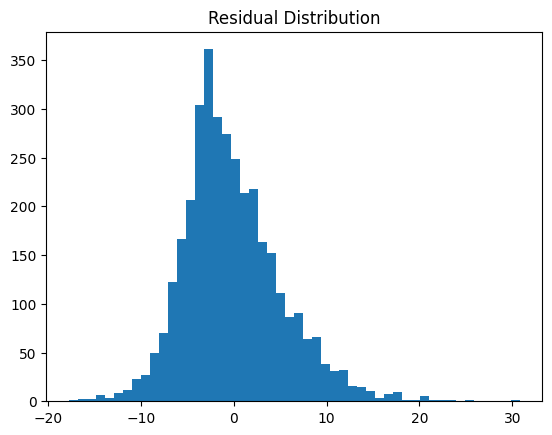

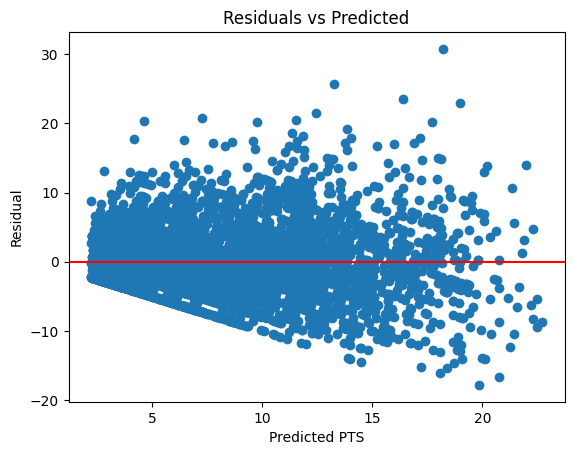

In [8]:
residuals = y_test - xgb_pred

# Distribution of errors
plt.hist(residuals, bins=50)
plt.title('Residual Distribution')
plt.show()

# Are errors random or structured?
plt.scatter(xgb_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel('Predicted PTS')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.show()

## Prediction Intervals — how confident is the model?

In [9]:
# Use quantile regression to get a range instead of a single number
from sklearn.ensemble import GradientBoostingRegressor

lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
mid   = GradientBoostingRegressor(loss='quantile', alpha=0.5)

lower.fit(x_train, y_train)
upper.fit(x_train, y_train)
mid.fit(x_train, y_train)

pred_low  = lower.predict(x_test)
pred_high = upper.predict(x_test)
pred_mid  = mid.predict(x_test)

# Coverage — what % of actuals fall within the interval?
coverage = ((y_test >= pred_low) & (y_test <= pred_high)).mean()
print(f"Coverage: {coverage:.2%}")  # want this close to 80%

Coverage: 73.81%


## Error by Segment — who is the model bad at?

In [10]:
results = x_test.copy()
results['ACTUAL']    = y_test.values
results['PREDICTED'] = xgb_pred
results['ERROR']     = abs(results['ACTUAL'] - results['PREDICTED'])

# Where is MAE highest?
print(results.groupby('STARTING')['ERROR'].mean())        # starters vs bench
print(results.groupby('IS_B2B')['ERROR'].mean())          # b2b games
print(results.groupby('GAME_NUMBER')['ERROR'].mean())     # early season vs late

# Error by predicted bucket
results['PRED_BUCKET'] = pd.cut(results['PREDICTED'], bins=[0,15,25,35,48])
print(results.groupby('PRED_BUCKET')['ERROR'].mean())

STARTING
0    3.584873
1    5.026756
Name: ERROR, dtype: float64
IS_B2B
0    4.045692
1    4.362765
Name: ERROR, dtype: float64
GAME_NUMBER
10    3.615387
11    3.363843
12    3.705057
13    4.221496
14    3.882631
        ...   
66    4.628055
67    5.527710
68    2.982470
69    3.093730
70    4.953686
Name: ERROR, Length: 61, dtype: float64
PRED_BUCKET
(0, 15]     3.919691
(15, 25]    5.707961
Name: ERROR, dtype: float64


## SHAP — why did the model predict this for a specific player?

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


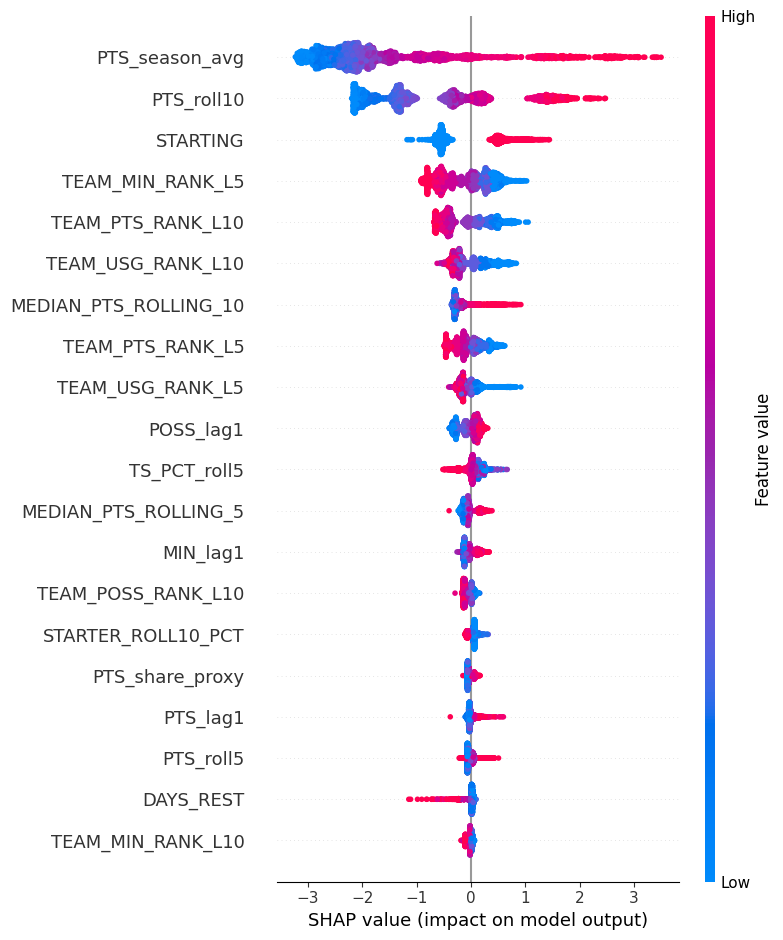

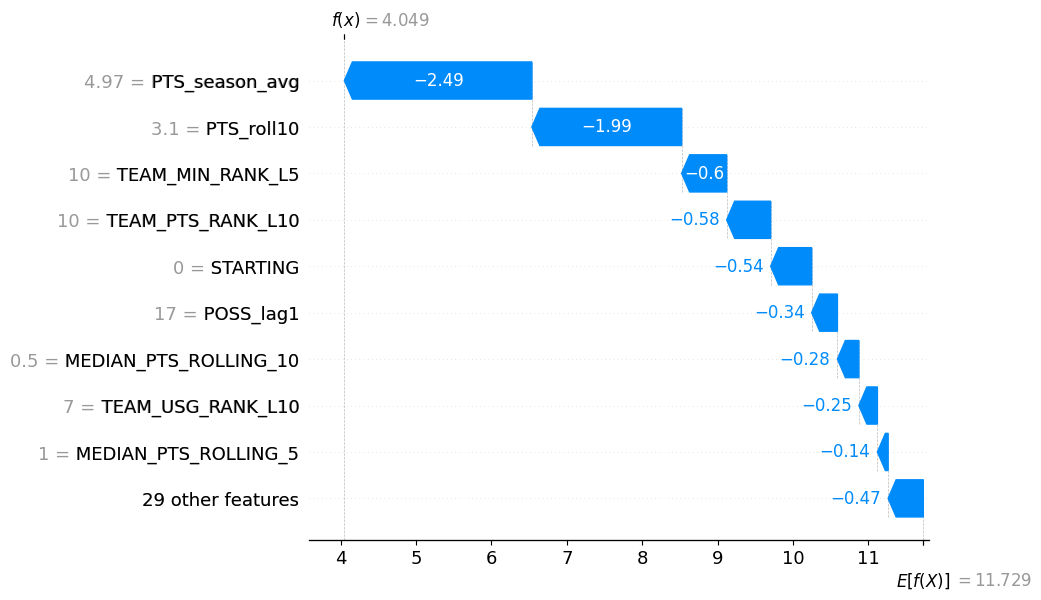

In [11]:
import shap

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(x_test) 

# Global feature importance
shap.summary_plot(shap_values, x_test, feature_names=features)

# Single prediction waterfall
shap.plots.waterfall(shap_values[1154])

## Calibration — is the model systematically biased?

In [12]:
results = pd.DataFrame({'actual': y_test.values, 'predicted': xgb_pred})

# Bin predictions and compare to actuals
results['bucket'] = pd.cut(results['predicted'], bins=10)
calibration = results.groupby('bucket').agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    count=('actual', 'count')
)
print(calibration)

                  mean_predicted  mean_actual  count
bucket                                              
(2.211, 4.28]           3.222593     2.750000    648
(4.28, 6.327]           5.337364     5.297753    712
(6.327, 8.375]          7.269044     6.987611    565
(8.375, 10.423]         9.322208     9.363029    449
(10.423, 12.471]       11.468349    12.070615    439
(12.471, 14.518]       13.411637    13.257426    303
(14.518, 16.566]       15.471337    14.554945    182
(16.566, 18.614]       17.538834    17.833333    132
(18.614, 20.662]       19.337597    17.621212     66
(20.662, 22.71]        21.606308    18.333333     21


## Walk-Forward Validation — does it hold up over time?

This is critical for sports — a single train/test split can mask that your model degrades late in the season.

---

**Are you ready to move to PTS?**

You're ready when:
```
✓ MAE on MIN is under ~3.5 minutes consistently across folds
✓ Residuals are roughly centered around 0 with no clear pattern
✓ Error by segment shows no single group is badly wrong
✓ Walk-forward scores are stable across folds (not degrading)

In [13]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_idx, test_idx in tscv.split(X):
    x_tr, x_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    xgb_model.fit(x_tr, y_tr)
    preds = xgb_model.predict(x_te)
    scores.append(mean_absolute_error(y_te, preds))

print(f"MAE per fold: {scores}")
print(f"Mean MAE: {sum(scores)/len(scores):.2f}")

MAE per fold: [4.857790470123291, 4.8764729499816895, 4.718282222747803, 4.291757583618164, 4.072002410888672]
Mean MAE: 4.56


## Pipeline

In [15]:

def pipeline(df, name):
    # minutes rank
    df = df.sort_values(by=['GAME_DATE', 'PLAYER_ID']).copy()
    df['min_l5'] = (
    df.groupby('PLAYER_ID')['MIN']
      .transform(lambda x: x.rolling(5).mean()).round(2))
    df['TEAM_MIN_RANK_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE'])['min_l5'].rank(ascending=False, method='dense'))

    # points rank
    df['pts_l5'] = (
    df.groupby('PLAYER_ID')['PTS']
      .transform(lambda x: x.rolling(5).mean()).round(2))
    df['TEAM_PTS_RANK_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE'])['pts_l5'].rank(ascending=False, method='dense'))

    df['pts_l10'] = (
    df.groupby('PLAYER_ID')['PTS']
      .transform(lambda x: x.rolling(10).mean()).round(2))
    df['TEAM_PTS_RANK_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE'])['pts_l10'].rank(ascending=False, method='dense'))

    # poss rank
    df['poss_l5'] = (
    df.groupby('PLAYER_ID')['POSS']
      .transform(lambda x: x.rolling(5).mean()).round(2))
    df['TEAM_POSS_RANK_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE'])['poss_l5'].rank(ascending=False, method='dense'))

    df['poss_l10'] = (
    df.groupby('PLAYER_ID')['POSS']
      .transform(lambda x: x.rolling(10).mean()).round(2))
    df['TEAM_POSS_RANK_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE'])['poss_l10'].rank(ascending=False, method='dense'))

    pdf = df[df['PLAYER_NAME'] == name].sort_values(by='GAME_DATE').copy()
    if len(pdf) < 5: 
        return None
    
    res = []

    res.append(pdf['PLAYER_ENC'].iloc[0])
    res.append(pdf['MIN'].tail(10).mean().round(2))
    res.append(pdf['MIN'].tail(5).mean().round(2))
    res.append(pdf['TEAM_MIN_RANK_L5'].iloc[-1])
    res.append(pdf['MIN'].tail(3).mean().round(2))
    team_abv = pdf['TEAM_ABBREVIATION'].iloc[-1]
    if name in projectedStartingFive[team_abv]:
        res.append(1)
    else:
        res.append(0)

    res.append(pdf['MIN'].mean().round(2))
    res.append(pdf['POSS'].tail(3).mean().round(2))
    res.append(pdf['MIN'].iloc[-1].round(2))
    res.append(pdf['POSS'].iloc[-1].round(2))
    res.append(pdf['STARTING'].iloc[-2])
    res.append(pdf['STARTING'].tail(10).mean())
    res.append(pdf['STARTING'].iloc[-1])
    #days rested
    last_game_date = pd.to_datetime(pdf['GAME_DATE'].iloc[-1]).normalize()
    today = pd.Timestamp.today().normalize()
    days_rested = (today - last_game_date).days
    res.append(days_rested)
    res.append(pdf['MIN'].tail(5).std().round(2))
    res.append(len(pdf))
    res.append(pdf['MIN'].tail(5).median().round(2))
    res.append(pdf['MIN'].tail(7).median().round(2))
    res.append(pdf['MIN'].tail(10).median().round(2))
    res.append(pdf['TEAM_PTS_RANK_L5'].iloc[-1])
    res.append(pdf['TEAM_PTS_RANK_L10'].iloc[-1])
    res.append(pdf['TEAM_POSS_RANK_L5'].iloc[-1])
    res.append(pdf['TEAM_POSS_RANK_L10'].iloc[-1])
    return res

In [16]:
propLines = pd.read_csv('propLines.csv')
propLines = propLines[(propLines['CATEGORY'] == 'player_points') & (propLines['BOOKMAKER'] == 'Underdog')]
propLines

,BOOKMAKER,CATEGORY,NAME,OVER/UNDER,LINE,ODDS,COMMENCE_TIME,LAST_UPDATE,DATA_PULLED_AT
0,Underdog,player_points,LaMelo Ball,Over,20.5,-137,2026-03-17,2026-03-17T21:30:30Z,2026-03-17 14:31:31
1,Underdog,player_points,LaMelo Ball,Under,20.5,-137,2026-03-17,2026-03-17T21:30:30Z,2026-03-17 14:31:31
2,Underdog,player_points,Tyler Herro,Over,22.5,-137,2026-03-17,2026-03-17T21:30:30Z,2026-03-17 14:31:31
3,Underdog,player_points,Tyler Herro,Under,22.5,-137,2026-03-17,2026-03-17T21:30:30Z,2026-03-17 14:31:31
4,Underdog,player_points,Miles Bridges,Over,15.5,-137,2026-03-17,2026-03-17T21:30:30Z,2026-03-17 14:31:31
...,...,...,...,...,...,...,...,...,...
111,Underdog,player_points,Julian Champagnie,Under,11.5,-137,2026-03-18,2026-03-17T21:31:29Z,2026-03-17 14:31:31
112,Underdog,player_points,Precious Achiuwa,Over,12.5,-137,2026-03-18,2026-03-17T21:31:29Z,2026-03-17 14:31:31
113,Underdog,player_points,Precious Achiuwa,Under,12.5,-137,2026-03-18,2026-03-17T21:31:29Z,2026-03-17 14:31:31
114,Underdog,player_points,Maxime Raynaud,Over,13.5,-137,2026-03-18,2026-03-17T21:31:29Z,2026-03-17 14:31:31


In [17]:
names = list(propLines['NAME'].unique())
print(names)
print(f"The feature set has {len(features)} features.")

res = {}

for name in names:
    if name in nameDict:
        name = nameDict[name]

    row = pipeline(data, name)

    # skip players with insufficient data
    if row is None:
        continue

    new_X = pd.DataFrame([row], columns=features)
    new_pred = xgb_model.predict(new_X)[0]

    mins_l5 = (
        data[data['PLAYER_NAME'] == name]['MIN']
        .tail(5)
        .mean()
        .round(2)
    )

    res[name] = {
        'PREDICTED_MINUTES': new_pred,
        'MINUTES_L5': mins_l5
    }

res_df = pd.DataFrame.from_dict(res, orient='index').reset_index()
res_df = res_df.rename(columns={'index': 'NAME'})

['LaMelo Ball', 'Tyler Herro', 'Miles Bridges', 'Jaime Jaquez Jr', 'Norman Powell', 'Davion Mitchell', 'Kon Knueppel', 'Ryan Kalkbrenner', 'Pelle Larsson', 'Jamir Watkins', 'Cade Cunningham', 'Tobias Harris', 'Carlton Carrington', 'Javonte Green', 'Justin Champagnie', 'Tristan Vukcevic', 'Anthony Gill', 'Shai Gilgeous-Alexander', 'Desmond Bane', 'Paolo Banchero', 'Chet Holmgren', 'Alex Caruso', 'Wendell Carter Jr', 'Luguentz Dort', 'Jevon Carter', 'Jordan Clarkson', 'Ivica Zubac', 'Josh Hart', 'Mikal Bridges', 'Aaron Nesmith', 'Mitchell Robinson', 'Kobe Brown', 'Giannis Antetokounmpo', 'James Harden', 'Donovan Mitchell', 'Kyle Kuzma', 'Evan Mobley', 'Myles Turner', 'Dennis Schroder', 'Thomas Bryant', 'Jaylon Tyson', 'Ryan Rollins', 'Sam Merrill', 'Julius Randle', 'Rudy Gobert', 'Oso Ighodaro', 'Nikola Jokic', 'VJ Edgecombe', 'Quentin Grimes', 'Adem Bona', 'Trendon Watford', 'DeMar DeRozan', 'Keldon Johnson', 'Stephon Castle', 'Malik Monk', 'Julian Champagnie', 'Precious Achiuwa', 'Maxi

ValueError: 24 columns passed, passed data had 23 columns

In [ ]:
res_df

,NAME,PREDICTED_MINUTES,MINUTES_L5
0,LaMelo Ball,29.523607,33.31
1,Tyler Herro,28.399176,31.31
2,Miles Bridges,29.790560,32.35
3,Jaime Jaquez Jr.,28.909281,29.18
4,Norman Powell,26.214033,30.32
5,Davion Mitchell,27.404564,27.46
6,Kon Knueppel,32.314022,28.93
7,Ryan Kalkbrenner,26.016914,27.48
8,Pelle Larsson,31.925592,14.68
9,Jamir Watkins,26.941347,6.61


In [ ]:
data[data['PLAYER_NAME'] == 'Justin Champagnie']

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION_x,STARTING_x,START_POSITION_y,STARTING_y,START_POSITION,STARTING,PLAYER_ENC
549,2021-22,1630551,Justin Champagnie,Justin,1610612761,TOR,Toronto Raptors,22101206,2022-04-08,TOR vs. HOU,W,7.183333,1,2,0.500,1,2,0.5,0,0,0.0,0,2,2,0,1,1,0,0,0,0,3,-8,7.4,0,0,8.0,1,7:11,1,107.7,105.6,105.6,147.4,142.1,142.1,-39.7,-36.5,-36.5,0.000,0.0,0.0,0.000,0.222,0.125,33.3,33.3,0.750,0.750,0.167,0.170,120.14,123.62,103.02,123.62,0.087,18,1.0,2.0,44,96,0.458,7,29,0.241,22,23,0.957,13,28,41,20,10.0,13,4,3,18,19,117,2.0,113.5,113.6,111.0,111.7,2.4,1.9,0.455,2.00,14.6,0.269,0.775,0.489,0.097,0.495,0.551,103.3,103.00,85.83,103,0.506,1610612761,TOR,Toronto Raptors,44,96,0.458,7,29,0.241,22,23,0.957,13,28,41,20,10.0,13,4,3,18,19,117,2.0,113.5,113.6,111.0,111.7,2.4,1.9,0.455,2.00,14.6,0.269,0.775,0.489,0.097,0.495,0.551,103.3,103.00,85.83,103,0.506,NaN,0.0,NaN,NaN,NaN,0,579
5970,2021-22,1630551,Justin Champagnie,Justin,1610612761,TOR,Toronto Raptors,22100458,2022-03-04,TOR vs. ORL,L,0.635000,0,0,0.000,0,0,0.0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,3,0.0,0,0,0.0,1,0:38,1,300.0,300.0,300.0,0.0,0.0,0.0,300.0,300.0,300.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,113.39,113.39,94.49,113.39,0.000,1,0.0,0.0,37,93,0.398,12,37,0.324,11,17,0.647,12,42,54,22,12.0,2,8,4,18,18,97,-6.0,96.5,96.0,99.8,101.0,-3.2,-4.9,0.595,1.83,16.2,0.220,0.729,0.475,0.119,0.462,0.483,101.9,101.50,84.58,101,0.463,1610612761,TOR,Toronto Raptors,37,93,0.398,12,37,0.324,11,17,0.647,12,42,54,22,12.0,2,8,4,18,18,97,-6.0,96.5,96.0,99.8,101.0,-3.2,-4.9,0.595,1.83,16.2,0.220,0.729,0.475,0.119,0.462,0.483,101.9,101.50,84.58,101,0.463,NaN,0.0,NaN,NaN,NaN,0,579
6533,2021-22,1630551,Justin Champagnie,Justin,1610612761,TOR,Toronto Raptors,22100726,2022-02-28,TOR @ BKN,W,9.816667,1,3,0.333,0,2,0.0,0,0,0.0,0,4,4,2,0,0,0,0,0,1,2,-2,9.8,0,0,8.0,1,9:49,1,112.6,109.1,109.1,112.1,118.2,118.2,0.5,-9.1,-9.1,0.222,0.0,40.0,0.000,0.333,0.167,0.0,0.0,0.333,0.333,0.130,0.134,108.84,107.57,89.64,107.57,0.111,22,1.0,3.0,51,99,0.515,18,38,0.474,13,22,0.591,16,31,47,35,13.0,17,5,5,20,20,133,36.0,125.9,131.7,91.9,97.0,34.0,34.7,0.686,2.69,22.3,0.396,0.611,0.505,0.129,0.606,0.612,105.6,100.50,83.75,101,0.683,1610612761,TOR,Toronto Raptors,51,99,0.515,18,38,0.474,13,22,0.591,16,31,47,35,13.0,17,5,5,20,20,133,36.0,125.9,131.7,91.9,97.0,34.0,34.7,0.686,2.69,22.3,0.396,0.611,0.505,0.129,0.606,0.612,105.6,100.50,83.75,101,0.683,NaN,0.0,NaN,